## **Product-Level Analysis**

This notebook builds a product-level summary, most profitable products, units sold, and seasonal patterns, from the transaction data, using the full dataset (all countries), since product performance shouldn't be limited to UK-only, unlike the market basket analysis, which specifically needed UK-only for a coherent recommendation set. This directly answers the marketing-oriented questions raised earlier: which products drive the most revenue, and when.

#### Planned Approach

1. Load transaction data, compute revenue and units sold per product
2. Rank products by total revenue and by units sold, since these can tell different stories, a high-volume, low-margin product versus a low-volume, high-value one
3. Identify seasonal patterns per product, which products spike in which months, useful for stock planning and campaign timing
4. Identify which customer segments (from `6_clustering.ipynb`) drive demand for which products, connecting product performance back to customer value
5. Save a clean product summary table for the app

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append("../src")
from config import CLEAN_DATA_PATH

df = pd.read_csv(CLEAN_DATA_PATH, parse_dates=["InvoiceDate"])
df['Revenue'] = df['Quantity'] * df['Price']

product_summary = df.groupby(['StockCode', 'Description']).agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Units_Sold=('Quantity', 'sum'),
    Order_Count=('Invoice', 'nunique'),
    Avg_Price=('Price', 'mean')
).reset_index()

print("Number of distinct products:", len(product_summary))
product_summary.sort_values('Total_Revenue', ascending=False).head(15)

Number of distinct products: 5308


,StockCode,Description,Total_Revenue,Total_Units_Sold,Order_Count,Avg_Price
1862,22423,REGENCY CAKESTAND 3 TIER,277656.25,24124,3317,12.461649
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,247048.01,91757,4888,2.870666
3283,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,2.080000
4725,85099B,JUMBO BAG RED RETROSPOT,134307.44,74224,2612,1.973870
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,124351.86,78234,2652,1.676152
3627,47566,PARTY BUNTING,103283.38,23460,2077,4.772912
2781,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,195,1.220303
1449,22086,PAPER CHAIN KIT 50'S CHRISTMAS,76598.18,28380,1691,2.919609
3931,79321,CHILLI LIGHTS,69084.30,14843,922,5.146039
4729,85099F,JUMBO BAG STRAWBERRY,64127.77,35842,1514,1.956918


"Paper Craft, Little Birdie" ranks third by total revenue (£168,469.60), but this entire figure comes from a single order (Order_Count = 1), the same 80,995-unit bulk wholesale purchase identified during EDA in `2_eda.ipynb`. This is meaningfully different from products like Regency Cakestand or White Hanging Heart T-Light Holder, whose revenue reflects broad, sustained demand across thousands of separate orders. Ranking products by total revenue alone can therefore overstate the reliability or breadth of a product's popularity, a product driven by one large order is a fragile revenue source compared to one purchased consistently by many different customers. We account for this distinction explicitly in the next step.

### Ranking Products, Revenue vs. Breadth of Demand

We compare products ranked by total revenue against products ranked by order count (breadth of demand), to distinguish reliably popular products from those whose revenue is concentrated in a small number of large orders.

In [2]:
print("Top 10 by Total Revenue:")
print(product_summary.sort_values('Total_Revenue', ascending=False)[['Description', 'Total_Revenue', 'Order_Count']].head(10))

Top 10 by Total Revenue:
                             Description  Total_Revenue  Order_Count
1862            REGENCY CAKESTAND 3 TIER      277656.25         3317
4751  WHITE HANGING HEART T-LIGHT HOLDER      247048.01         4888
3283         PAPER CRAFT , LITTLE BIRDIE      168469.60            1
4725             JUMBO BAG RED RETROSPOT      134307.44         2612
4456       ASSORTED COLOUR BIRD ORNAMENT      124351.86         2652
3627                       PARTY BUNTING      103283.38         2077
2781      MEDIUM CERAMIC TOP STORAGE JAR       81416.73          195
1449     PAPER CHAIN KIT 50'S CHRISTMAS        76598.18         1691
3931                       CHILLI LIGHTS       69084.30          922
4729                JUMBO BAG STRAWBERRY       64127.77         1514


In [3]:
print("Top 10 by Order Count (breadth of demand):")
print(product_summary.sort_values('Order_Count', ascending=False)[['Description', 'Total_Revenue', 'Order_Count']].head(10))

Top 10 by Order Count (breadth of demand):
                             Description  Total_Revenue  Order_Count
4751  WHITE HANGING HEART T-LIGHT HOLDER      247048.01         4888
1862            REGENCY CAKESTAND 3 TIER      277656.25         3317
4456       ASSORTED COLOUR BIRD ORNAMENT      124351.86         2652
4725             JUMBO BAG RED RETROSPOT      134307.44         2612
3627                       PARTY BUNTING      103283.38         2077
281              LUNCH BAG  BLACK SKULL.       39904.00         1997
1810          LUNCH BAG SPACEBOY DESIGN        30131.70         1874
505         REX CASH+CARRY JUMBO SHOPPER        3689.80         1857
1177            HOME BUILDING BLOCK WORD       42453.11         1831
679       STRAWBERRY CERAMIC TRINKET BOX       39682.67         1818


In [5]:
# Flag products with high revenue but suspiciously low order count, a concentration risk
product_summary['Revenue_Per_Order'] = product_summary['Total_Revenue'] / product_summary['Order_Count']
print("Top 10 by Revenue Per Order (highest concentration risk, at least 5 orders):")
print(product_summary[product_summary['Order_Count'] >= 5].sort_values('Revenue_Per_Order', ascending=False)[['Description', 'Total_Revenue', 'Order_Count', 'Revenue_Per_Order']].head(10))

Top 10 by Revenue Per Order (highest concentration risk, at least 5 orders):
                             Description  Total_Revenue  Order_Count  \
4876     SMALL FAIRY CAKE FRIDGE MAGNETS        6875.00            5   
2781      MEDIUM CERAMIC TOP STORAGE JAR       81416.73          195   
2351         HALL CABINET WITH 3 DRAWERS        4013.59           11   
2137        VINTAGE BLUE KITCHEN CABINET        9290.00           37   
2136         VINTAGE RED KITCHEN CABINET       12550.00           52   
2344        REGENCY MIRROR WITH SHUTTERS        2565.00           11   
2347           UTILTY CABINET WITH HOOKS        3623.20           16   
2342    GIANT SEVENTEEN DRAWER SIDEBOARD        1240.00            6   
356                      GOLD WINE GLASS        1229.04            6   
2343  RUSTIC  SEVENTEEN DRAWER SIDEBOARD        5910.00           29   

      Revenue_Per_Order  
4876        1375.000000  
2781         417.521692  
2351         364.871818  
2137         251.081081  


The Revenue Per Order ranking surfaces a coherent pattern beyond isolated outliers: a cluster of furniture items, Hall Cabinet with 3 Drawers, Vintage Blue/Red Kitchen Cabinets, Regency Mirror with Shutters, Utility Cabinet, and Seventeen Drawer Sideboards, all show high revenue-per-order despite modest order counts. Unlike Paper Craft, Little Birdie (a single bulk order distorting one product's figures), this is a genuine product category signal, furniture is inherently higher-value per unit than the retailer's typical small gift-ware items, so naturally commands a higher revenue-per-order even with fewer total transactions. This is a useful, actionable finding: these products represent a smaller but higher-value customer segment worth separate marketing treatment, likely appealing to a different kind of buyer than the retailer's typical high-volume trinket purchasers.

Medium Ceramic Top Storage Jar (£81,417 revenue across only 195 orders, ranked 7th by total revenue but far lower by order count) likely reflects a similar bulk-order pattern to Paper Craft, Little Birdie, worth treating its revenue rank with appropriate caution rather than as a broad-demand bestseller.

We inspect the individual transactions behind Small Fairy Cake Fridge Magnets and Medium Ceramic Top Storage Jar directly, to confirm whether their high per-order or total revenue figures are driven by one or a few unusually large orders, similar to Paper Craft, Little Birdie.

In [6]:
suspect_products = ['SMALL FAIRY CAKE FRIDGE MAGNETS', 'MEDIUM CERAMIC TOP STORAGE JAR']

for product in suspect_products:
    print(f"{product}")
    product_orders = df[df['Description'] == product].groupby('Invoice').agg(
        Quantity=('Quantity', 'sum'),
        Revenue=('Revenue', 'sum')
    ).sort_values('Revenue', ascending=False)
    print(product_orders.head(10))
    print(f"Total orders: {len(product_orders)}")
    print()

SMALL FAIRY CAKE FRIDGE MAGNETS
         Quantity  Revenue
Invoice                   
497946       2504   3630.8
498152       9456   2836.8
489676        240    348.0
494473         24     39.6
492092         12     19.8
Total orders: 5

MEDIUM CERAMIC TOP STORAGE JAR
         Quantity   Revenue
Invoice                    
541431      74215  77183.60
561901        288    360.00
553607        240    249.60
561051        144    149.76
563614         96     99.84
580665         96     99.84
556917         96     99.84
554307         96     99.84
577669         96     99.84
552882         96     99.84
Total orders: 195



Small Fairy Cake Fridge Magnets: the top two orders alone account for 94% of total revenue (£6,467.60 of £6,875.00), out of just 5 orders total.

Medium Ceramic Top Storage Jar: a single order (74,215 units, £77,183.60) accounts for 94.8% of the product's entire £81,417 total revenue across all 195 orders, this is the same bulk order identified during Quantity outlier investigation in `2_eda.ipynb` (Customer 12346).

Both confirm the same pattern as Paper Craft, Little Birdie: a small number of extreme wholesale orders can make a product appear far more significant in total-revenue rankings than its actual breadth of customer demand would suggest. This reinforces the value of reporting Order_Count and Revenue_Per_Order alongside Total_Revenue in any product ranking presented to a business owner, since revenue alone can be materially misleading for products with this kind of concentrated order history.

### Seasonal Patterns Per Product

We examine monthly sales patterns for the top products by revenue, to identify which products spike around the retailer's known October-November seasonal peak (identified in `2_eda.ipynb`) versus those with steady, year-round demand. This is useful for stock planning and campaign timing.

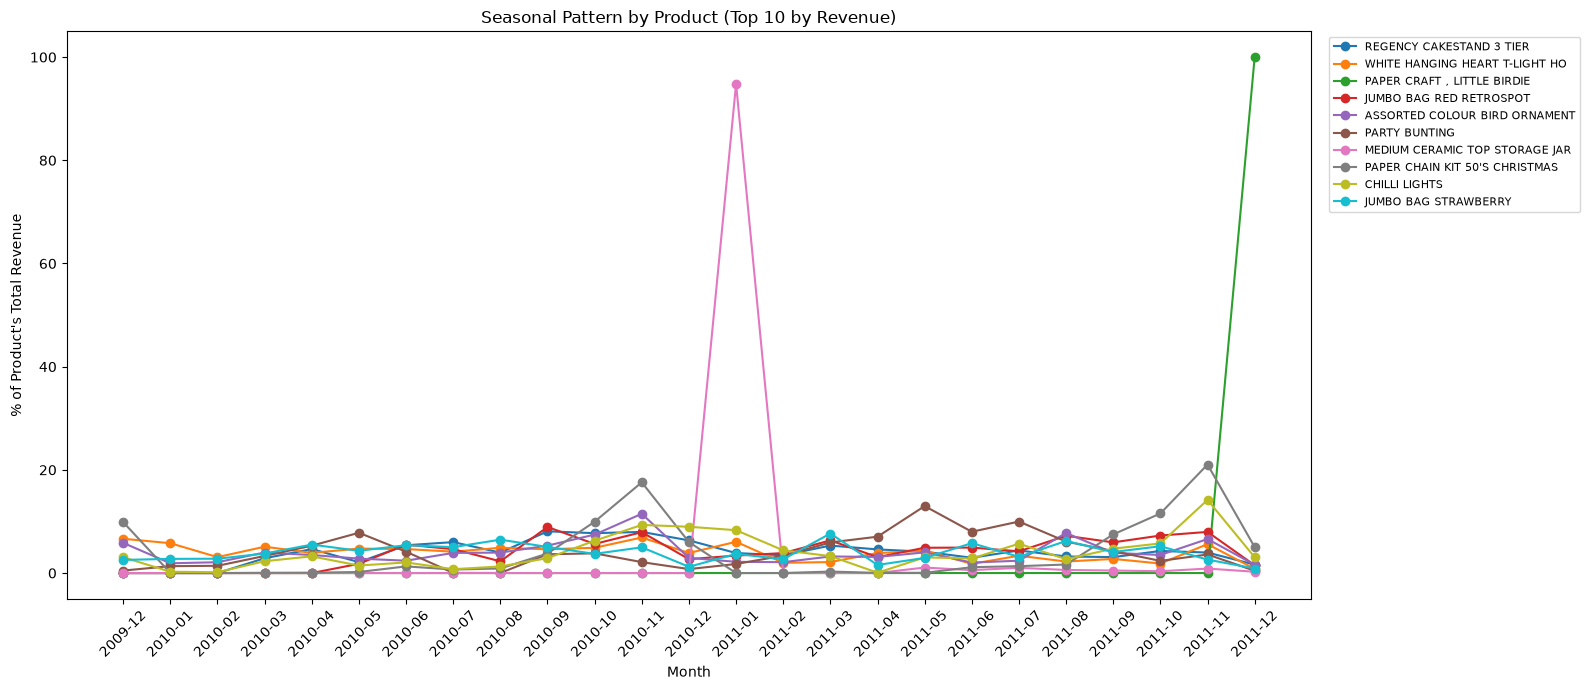

In [7]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

top_10_products = product_summary.sort_values('Total_Revenue', ascending=False).head(10)['Description'].tolist()

monthly_product_sales = df[df['Description'].isin(top_10_products)].groupby(
    ['Description', 'YearMonth']
)['Revenue'].sum().unstack(fill_value=0)

# Normalize each product's row to show relative pattern (% of that product's own total), so products
# of very different absolute scale can be compared on the same chart
monthly_product_pct = monthly_product_sales.div(monthly_product_sales.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 7))
for product in top_10_products:
    if product in monthly_product_pct.index:
        ax.plot(monthly_product_pct.columns.astype(str), monthly_product_pct.loc[product], marker='o', label=product[:30])

ax.set_xlabel('Month')
ax.set_ylabel('% of Product\'s Total Revenue')
ax.set_title('Seasonal Pattern by Product (Top 10 by Revenue)')
ax.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Paper Craft, Little Birdie (100% in 2011-12) and Medium Ceramic Top Storage Jar (95% in 2011-01) show dramatic single-month spikes, but these are not genuine seasonality, they are the same single bulk orders identified earlier (80,995 and 74,215 units respectively), landing entirely within one month. These spikes are an artifact of order concentration, not a seasonal buying pattern, and should be excluded from any seasonal planning based on this chart.

Among the remaining 8 products, the pattern is more genuinely informative: Paper Chain Kit 50's Christmas shows a real, modest seasonal bump in November of both years (10% and 21% of its annual total), consistent with its Christmas-themed nature. Most other top products (Regency Cakestand, White Hanging Heart T-Light Holder, Jumbo Bag Red Retrospot, Assorted Colour Bird Ornament) show relatively flat, steady demand throughout the year, generally under 10% of annual revenue in any single month, indicating these are reliable, year-round bestsellers rather than seasonal items, despite the retailer's overall October-November seasonal peak identified at the business level in `2_eda.ipynb`.

This distinction matters for stock planning: business-level seasonality (driven by overall customer volume increasing in Oct-Nov) does not mean every individual product is itself seasonal, most top products sell consistently, and the increased Oct-Nov revenue likely comes from more customers buying the same steady-selling products, rather than from seasonal products spiking specifically.

#### Re-Examining Seasonality, Outliers Excluded

We re-plot the seasonal pattern excluding Paper Craft, Little Birdie and Medium Ceramic Top Storage Jar, whose single-order spikes distort the chart and obscure the genuine, more subtle seasonal patterns in the remaining products.

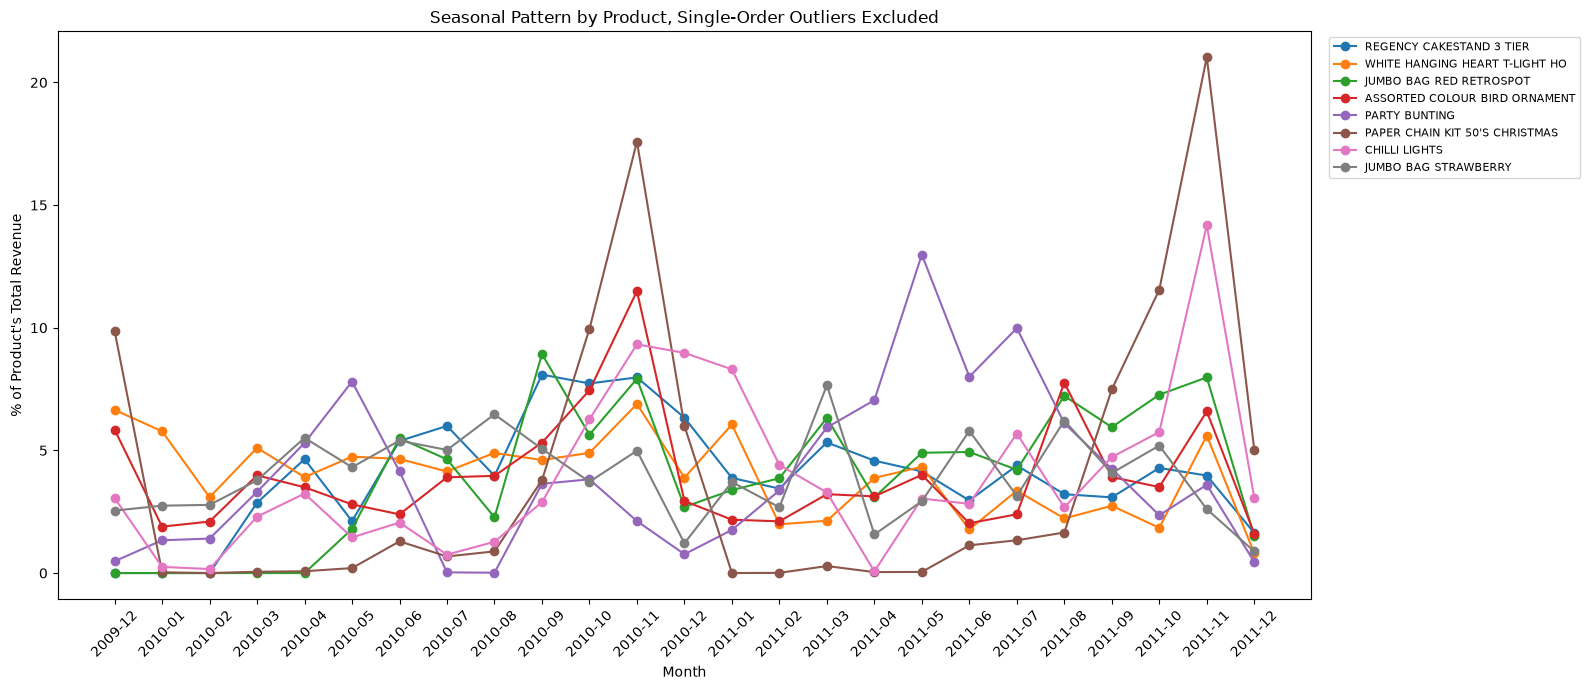

In [8]:
outlier_products = ['PAPER CRAFT , LITTLE BIRDIE', 'MEDIUM CERAMIC TOP STORAGE JAR']
clean_top_products = [p for p in top_10_products if p not in outlier_products]

fig, ax = plt.subplots(figsize=(16, 7))
for product in clean_top_products:
    if product in monthly_product_pct.index:
        ax.plot(monthly_product_pct.columns.astype(str), monthly_product_pct.loc[product], marker='o', label=product[:30])

ax.set_xlabel('Month')
ax.set_ylabel('% of Product\'s Total Revenue')
ax.set_title('Seasonal Pattern by Product, Single-Order Outliers Excluded')
ax.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

With the two single-order outliers excluded, genuine seasonal patterns are now visible. Paper Chain Kit 50's Christmas shows the clearest seasonal signal of all top products, peaking sharply each November (17.6% in 2010, 21.1% in 2011), directly consistent with its Christmas theme. Chilli Lights and Assorted Colour Bird Ornament show similar, though less pronounced, November peaks, also consistent with holiday decoration buying.

The remaining products, Regency Cakestand, White Hanging Heart T-Light Holder, Jumbo Bag Red Retrospot, Jumbo Bag Strawberry, Party Bunting, remain relatively flat across the year (generally 2-8% of annual revenue per month), with no month dominating, confirming these are genuinely steady, year-round bestsellers rather than seasonal items. This directly supports the earlier distinction: the business's overall October-November seasonal peak appears driven by a mix of genuinely seasonal products (Christmas-themed decorations) plus increased volume of steady-selling products, rather than the entire catalog spiking together. This has a concrete business implication: stock planning ahead of the holiday season should prioritize scaling up Christmas-themed items specifically, while ensuring adequate supply of steady bestsellers, rather than assuming uniform seasonal demand across the full catalog.

### Which Segments Drive Demand for Which Products

We connect product-level demand back to the customer segments identified in `6_clustering.ipynb`, to see whether different segments show distinct product preferences, useful for tailoring segment-specific marketing.

In [9]:
cluster_data = pd.read_csv("../data/customer_clusters.csv", index_col=0)

df_with_segment = df.merge(
    cluster_data[['Segment_Name']],
    left_on='Customer ID', right_index=True, how='inner'
)

print("Transactions matched to a segment:", len(df_with_segment), "out of", len(df))

# Top product by revenue, within each segment
top_product_by_segment = df_with_segment.groupby(['Segment_Name', 'Description'])['Revenue'].sum().reset_index()
top_product_by_segment = top_product_by_segment.sort_values('Revenue', ascending=False).groupby('Segment_Name').head(5)

for segment in top_product_by_segment['Segment_Name'].unique():
    print(f"{segment}")
    print(top_product_by_segment[top_product_by_segment['Segment_Name'] == segment][['Description', 'Revenue']].to_string(index=False))

Transactions matched to a segment: 725729 out of 776641
Typical Steady
                       Description   Revenue
       PAPER CRAFT , LITTLE BIRDIE 168469.60
          REGENCY CAKESTAND 3 TIER 136373.05
WHITE HANGING HEART T-LIGHT HOLDER 134959.09
                     PARTY BUNTING  65170.50
     ASSORTED COLOUR BIRD ORNAMENT  64203.04
High-Value Regulars
                       Description  Revenue
          REGENCY CAKESTAND 3 TIER 94130.55
    MEDIUM CERAMIC TOP STORAGE JAR 78254.58
WHITE HANGING HEART T-LIGHT HOLDER 64620.09
           JUMBO BAG RED RETROSPOT 50634.17
     ASSORTED COLOUR BIRD ORNAMENT 43834.16
Elite Wholesalers
                      Description  Revenue
     VINTAGE UNION JACK MEMOBOARD 26544.88
WOOD BLACK BOARD ANT WHITE FINISH 24664.45
          CREAM HEART CARD HOLDER 23426.54
         REGENCY CAKESTAND 3 TIER 21944.25
          BLACK HEART CARD HOLDER 19411.76
At-Risk/Lapsed
                       Description  Revenue
WHITE HANGING HEART T-LIGHT HOLDER 24662

Two known single-order outliers reappear in these rankings: Paper Craft, Little Birdie dominates Typical Steady's top products, and Medium Ceramic Top Storage Jar dominates High-Value Regulars', the same bulk orders identified repeatedly throughout this project (EDA, product ranking, seasonality analysis). These segment rankings should be read with the same caution, a single large order from one customer can distort even segment-level product preferences.

The more genuinely interesting finding is Elite Wholesalers' distinct product mix: Vintage Union Jack Memoboard, Wood Black Board Ant White Finish, Cream Heart Card Holder, and Black Heart Card Holder, none of which appear in the overall top-10 products or in any other segment's top 5. This indicates our 5 elite wholesale customers are not simply purchasing more of the retailer's general bestsellers at higher volume, they are sourcing from a genuinely different part of the product catalog. This is a real, actionable insight: marketing or account management for this specific segment should be built around their actual purchasing patterns, not assumptions extrapolated from the general bestseller list, which would largely miss what this segment actually buys.

#### Segment Product Preferences (Outliers Excluded)

We repeat the segment breakdown excluding the two known single-order-driven products, to see each segment's genuine top products without distortion.

In [10]:
df_with_segment_clean = df_with_segment[~df_with_segment['Description'].isin(outlier_products)]

top_product_by_segment_clean = df_with_segment_clean.groupby(['Segment_Name', 'Description'])['Revenue'].sum().reset_index()
top_product_by_segment_clean = top_product_by_segment_clean.sort_values('Revenue', ascending=False).groupby('Segment_Name').head(5)

for segment in top_product_by_segment_clean['Segment_Name'].unique():
    print(f"{segment}")
    print(top_product_by_segment_clean[top_product_by_segment_clean['Segment_Name'] == segment][['Description', 'Revenue']].to_string(index=False))

Typical Steady
                       Description   Revenue
          REGENCY CAKESTAND 3 TIER 136373.05
WHITE HANGING HEART T-LIGHT HOLDER 134959.09
                     PARTY BUNTING  65170.50
     ASSORTED COLOUR BIRD ORNAMENT  64203.04
           JUMBO BAG RED RETROSPOT  62197.56
High-Value Regulars
                        Description  Revenue
           REGENCY CAKESTAND 3 TIER 94130.55
 WHITE HANGING HEART T-LIGHT HOLDER 64620.09
            JUMBO BAG RED RETROSPOT 50634.17
      ASSORTED COLOUR BIRD ORNAMENT 43834.16
ROTATING SILVER ANGELS T-LIGHT HLDR 32491.35
Elite Wholesalers
                      Description  Revenue
     VINTAGE UNION JACK MEMOBOARD 26544.88
WOOD BLACK BOARD ANT WHITE FINISH 24664.45
          CREAM HEART CARD HOLDER 23426.54
         REGENCY CAKESTAND 3 TIER 21944.25
          BLACK HEART CARD HOLDER 19411.76
At-Risk/Lapsed
                       Description  Revenue
WHITE HANGING HEART T-LIGHT HOLDER 24662.15
          REGENCY CAKESTAND 3 TIER 19390.05
  

With outliers removed, Typical Steady, High-Value Regulars, and At-Risk/Lapsed all show overlapping mainstream bestsellers, Regency Cakestand, White Hanging Heart T-Light Holder, Assorted Colour Bird Ornament, Jumbo Bag Red Retrospot, appearing across all three, differing mainly in revenue scale and ranking order rather than product identity. This confirms these three segments differ primarily in purchasing volume and frequency, not in fundamental product preference, they draw from the same core catalog.

Elite Wholesalers' top 5 is entirely unchanged after removing the outlier products, since none of their top items were ever among the flagged outliers, confirming this segment's distinct product mix (Vintage Union Jack Memoboard, Wood Black Board Ant White Finish, Cream/Black Heart Card Holder) is a genuine, stable finding rather than an artifact. This is the clearest actionable insight from this section: marketing and product strategy for the three larger segments can reasonably center on the general bestseller catalog, but Elite Wholesalers require a distinctly different approach, built around their actual, different purchasing pattern.

### Save the Product Summary Table

We save the product-level summary, including revenue, units sold, order count, and the outlier flag, for use in the deployment app's product analysis features.

In [11]:
product_summary['Is_Outlier_Driven'] = product_summary['Description'].isin(outlier_products)

PRODUCT_SUMMARY_PATH = "../data/product_summary.csv"
product_summary.to_csv(PRODUCT_SUMMARY_PATH, index=False)

print(f"Product summary saved to {PRODUCT_SUMMARY_PATH}")
print(f"Total products: {len(product_summary)}")

Product summary saved to ../data/product_summary.csv
Total products: 5308


### Summary

This notebook builds a product-level analysis using the full transaction dataset (all countries, unlike the UK-only market basket analysis), identifying the most profitable products, seasonal patterns, and segment-specific preferences.

**Key findings:**

- **5,308 distinct products analyzed**, ranked by total revenue, units sold, order count, and revenue per order.
- **A recurring pattern across the whole project reappeared here**: two products, Paper Craft, Little Birdie and Medium Ceramic Top Storage Jar, rank highly by total revenue but are almost entirely driven by a single extreme bulk order (94% and 94.8% of their respective total revenue), the same orders identified during Quantity outlier investigation in `2_eda.ipynb`. This reinforces the value of reporting order count and revenue-per-order alongside total revenue, rather than revenue alone, when presenting product rankings.
- **A genuine furniture product category emerged** from the Revenue Per Order ranking (cabinets, sideboards, mirrors), a coherent, distinct high-value category rather than a data artifact, worth separate marketing consideration.
- **Seasonal analysis, outliers excluded, revealed a clear signal**: Christmas-themed products (Paper Chain Kit 50's Christmas, Chilli Lights, Assorted Colour Bird Ornament) show genuine November peaks, while most top products sell steadily year-round. Business-level seasonality (identified in `2_eda.ipynb`) appears driven by a mix of genuinely seasonal items plus increased volume of steady sellers, not uniform seasonality across the catalog.
- **Segment-product analysis revealed a clear split**: Typical Steady, High-Value Regulars, and At-Risk/Lapsed customers draw from the same core bestseller catalog, differing mainly in purchase volume. Elite Wholesalers show a genuinely distinct product mix, unrelated to the general bestseller list, confirmed stable even after removing outlier products.

**Output:** A product-level summary table (`data/product_summary.csv`, 5,308 products with revenue, units sold, order count, and an outlier flag) ready for use in the deployment app's product analysis and "most profitable products" features.